In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import squarify


In [ ]:
%pip install squarify

Note: you may need to restart the kernel to use updated packages.


In [ ]:
#Call the data
data = pd.read_csv('/Users/anpabelt/Downloads/Video Game Analysis/video_games_sales.csv')
data

,rank,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [69]:
#Checking data columns
data.columns

Index(['rank', 'name', 'platform', 'year', 'genre', 'publisher', 'na_sales',
       'eu_sales', 'jp_sales', 'other_sales', 'global_sales'],
      dtype='object')

In [77]:
#Checking data information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rank          16598 non-null  int64  
 1   name          16598 non-null  object 
 2   platform      16598 non-null  object 
 3   year          16598 non-null  int64  
 4   genre         16598 non-null  object 
 5   publisher     16598 non-null  object 
 6   na_sales      16598 non-null  float64
 7   eu_sales      16598 non-null  float64
 8   jp_sales      16598 non-null  float64
 9   other_sales   16598 non-null  float64
 10  global_sales  16598 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.4+ MB


In [71]:
#Filling missing values in year column using median value
data["year"].fillna(data["year"].median(), inplace = True) 

In [72]:
#Filling missing values in publisher column using mode value
data["publisher"].fillna("unknown", inplace = True) 

In [73]:
data.isna().sum()

rank            0
name            0
platform        0
year            0
genre           0
publisher       0
na_sales        0
eu_sales        0
jp_sales        0
other_sales     0
global_sales    0
dtype: int64

In [76]:
#Changing year data type from float64 to int64

data["year"] = data["year"].astype('int64')

In [75]:
round(data.describe(), 2)

,rank,year,na_sales,eu_sales,jp_sales,other_sales,global_sales
count,16598.00,16598.00,16598.00,16598.00,16598.00,16598.00,16598.00
mean,8300.61,2006.42,0.26,0.15,0.08,0.05,0.54
std,4791.85,5.78,0.82,0.51,0.31,0.19,1.56
min,1.00,1980.00,0.00,0.00,0.00,0.00,0.01
25%,4151.25,2003.00,0.00,0.00,0.00,0.00,0.06
50%,8300.50,2007.00,0.08,0.02,0.00,0.01,0.17
75%,12449.75,2010.00,0.24,0.11,0.04,0.04,0.47
max,16600.00,2020.00,41.49,29.02,10.22,10.57,82.74


In [78]:
data[data.duplicated(keep = False)]

,rank,name,platform,year,genre,publisher,na_sales,eu_sales,jp_sales,other_sales,global_sales


In [82]:
genre_counts = data["genre"].value_counts()
genre_counts

genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Strategy         681
Puzzle           582
Name: count, dtype: int64

In [145]:
publisher_games = data["publisher"].value_counts()
publisher_games

publisher
Electronic Arts                 1351
Activision                       975
Namco Bandai Games               932
Ubisoft                          921
Konami Digital Entertainment     832
                                ... 
Glams                              1
Locus                              1
Warp                               1
Elite                              1
UIG Entertainment                  1
Name: count, Length: 579, dtype: int64

In [203]:
year_min = data.year.max()
year_min

2020

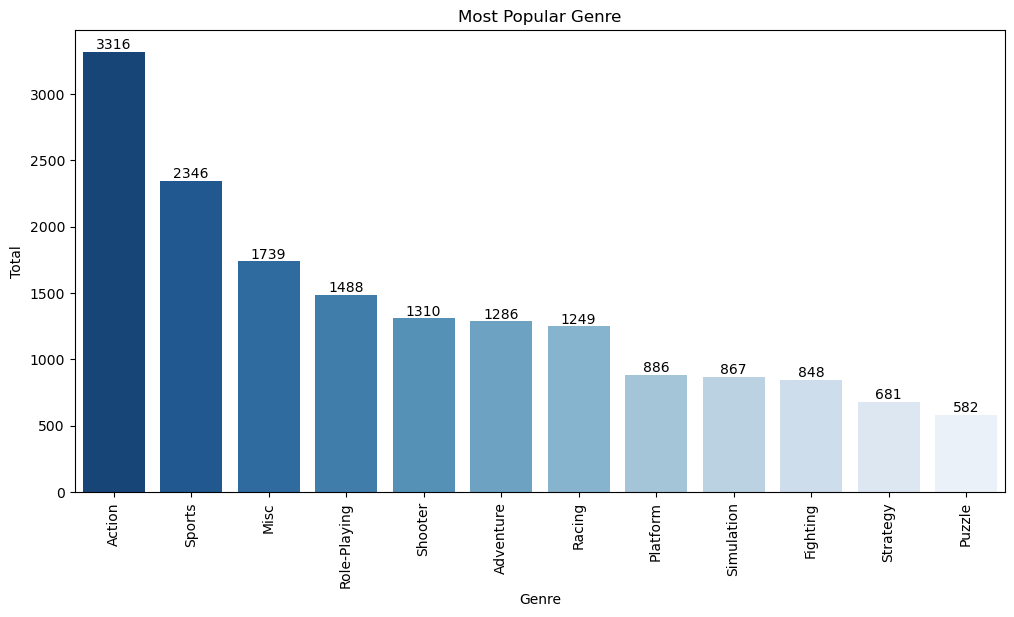

In [217]:
plt.figure(figsize=(12,6))
ax_genre = sns.barplot(x = genre_counts.index, y = genre_counts.values, palette=sns.color_palette("Blues_r", len(genre_counts)))

ax_genre.bar_label(ax_genre.containers[0])

plt.xticks(rotation=90)
plt.title('Most Popular Genre')
plt.xlabel('Genre')
plt.ylabel('Total')
plt.show()

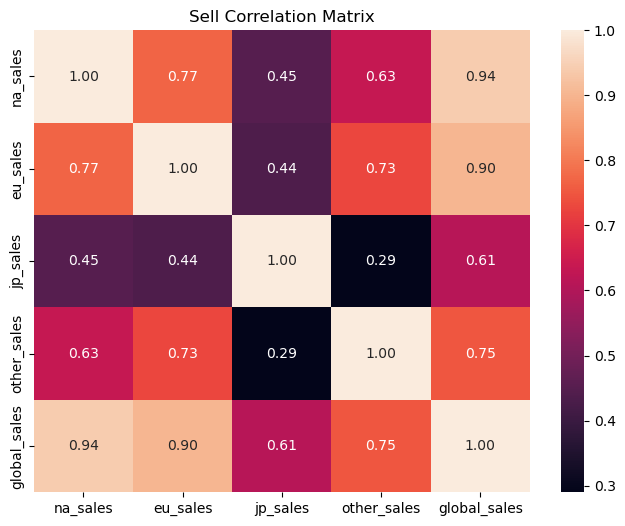

In [212]:
correlation = data[["na_sales", "eu_sales", "jp_sales", "other_sales", "global_sales"]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, robust=True, fmt=".2f")
plt.title("Sell Correlation Matrix")
plt.show()


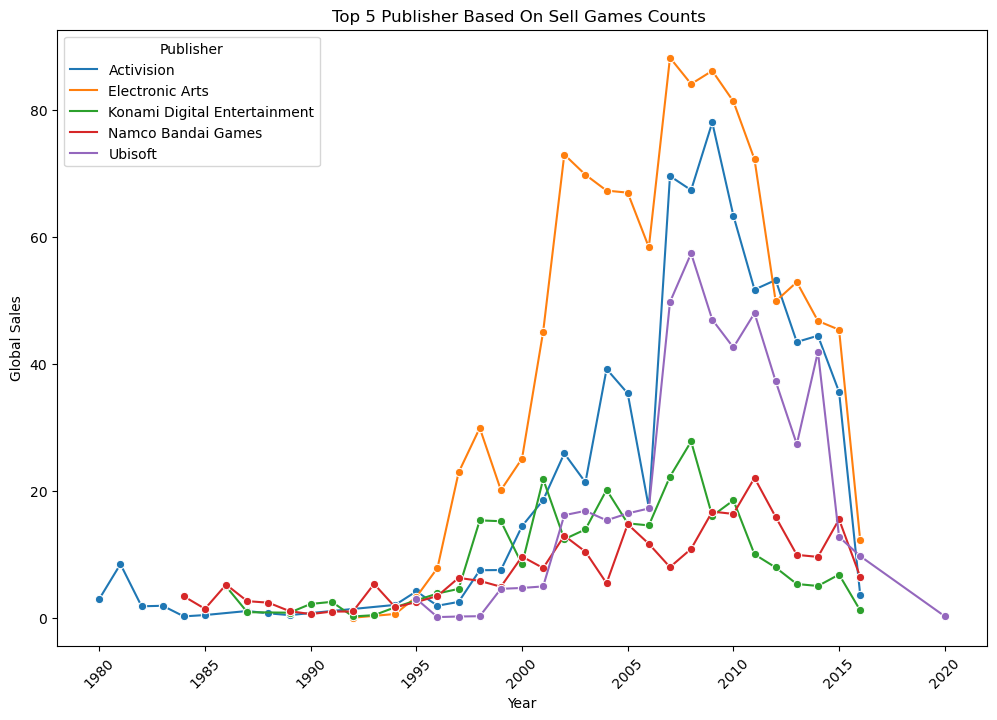

In [149]:
top_publishers_by_games = data['publisher'].value_counts().sort_values(ascending=False).head(5).index


top_publishers_data = data[data['publisher'].isin(top_publishers_by_games)]


publisher_year_sales = top_publishers_data.groupby(['publisher', 'year'])['global_sales'].sum().reset_index()


plt.figure(figsize=(12,8))
sns.lineplot(data=publisher_year_sales, x='year', y='global_sales', hue='publisher', marker="o")


plt.title('Top 5 Publisher Based On Sell Games Counts ')
plt.xlabel('Year')
plt.ylabel('Global Sales')
plt.legend(title='Publisher')
plt.xticks(rotation=45)
plt.show()

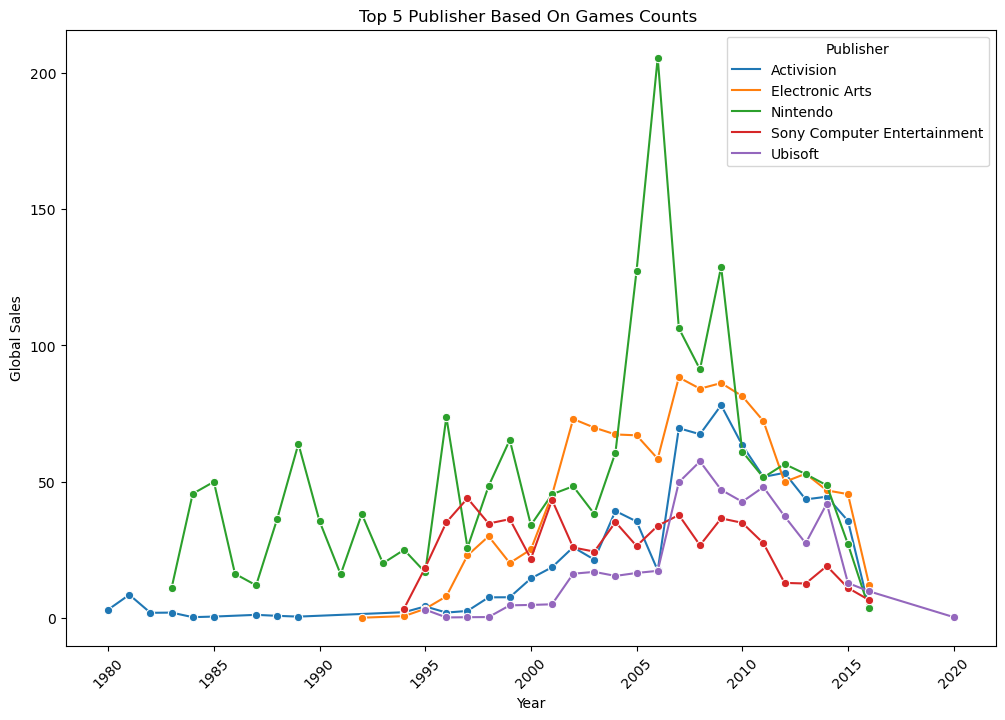

In [204]:

top_publishers = data.groupby('publisher')['global_sales'].sum().sort_values(ascending=False).head(5).index


top_publishers_data = data[data['publisher'].isin(top_publishers)]


publisher_year_sales = top_publishers_data.groupby(['publisher', 'year'])['global_sales'].sum().reset_index()


plt.figure(figsize=(12,8))
sns.lineplot(data=publisher_year_sales, x='year', y='global_sales', hue='publisher', marker="o")


plt.title('Top 5 Publisher Based On Games Counts ')
plt.xlabel('Year')
plt.ylabel('Global Sales')
plt.legend(title='Publisher')
plt.xticks(rotation=45)
plt.show()



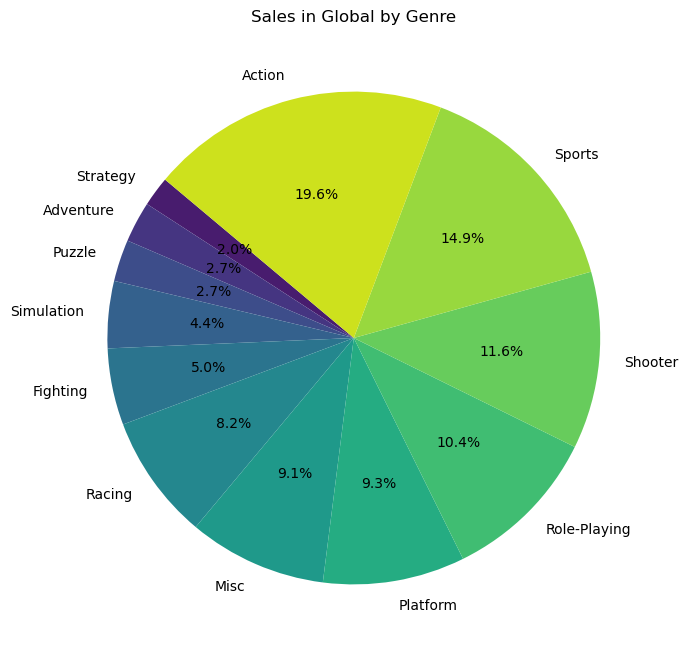

In [183]:
global_sales_by_genre = data.groupby('genre')['global_sales'].sum().sort_values(ascending=True)


colors = sns.color_palette('viridis', len(global_sales_by_genre))

plt.figure(figsize=(8,8))
plt.pie(global_sales_by_genre, labels=global_sales_by_genre.index, autopct='%1.1f%%', startangle=140, colors=colors)

plt.title("Sales in Global by Genre")


plt.show()

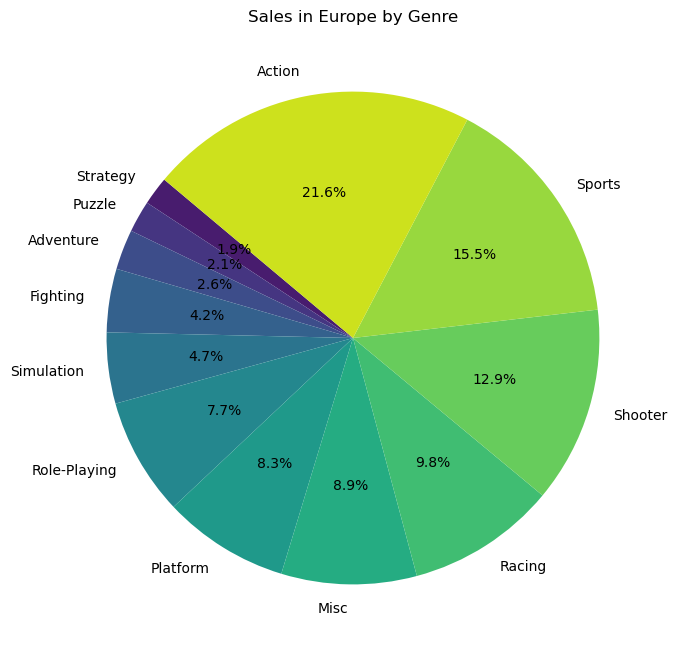

In [185]:
eu_sales_by_genre = data.groupby('genre')['eu_sales'].sum().sort_values(ascending=True)



colors = sns.color_palette('viridis', len(global_sales_by_genre))

plt.figure(figsize=(8,8))
plt.pie(eu_sales_by_genre, labels=eu_sales_by_genre.index, autopct='%1.1f%%', startangle=140, colors=colors)

plt.title("Sales in Europe by Genre")

plt.show()

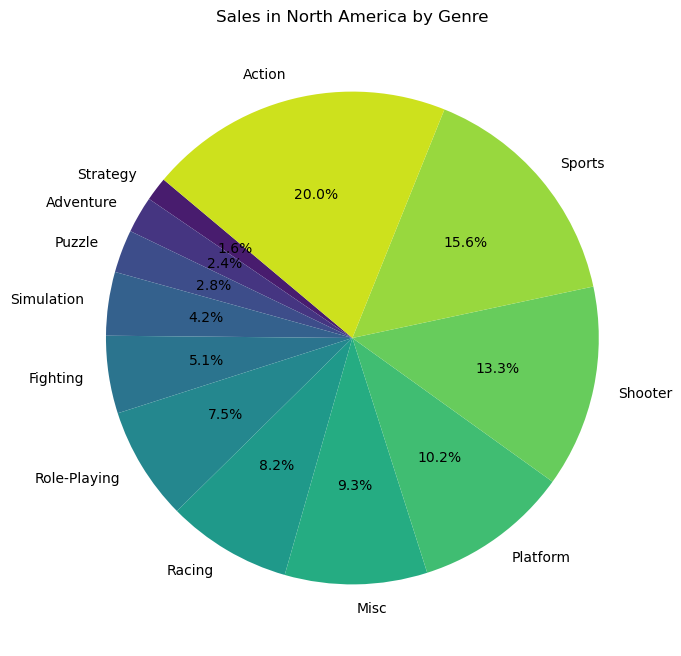

In [187]:
na_sales_by_genre = data.groupby('genre')['na_sales'].sum().sort_values(ascending=True)


colors = sns.color_palette('viridis', len(global_sales_by_genre))


plt.figure(figsize=(8,8))
plt.pie(na_sales_by_genre, labels=na_sales_by_genre.index, autopct='%1.1f%%', startangle=140, colors=colors)

plt.title("Sales in North America by Genre")

plt.show()

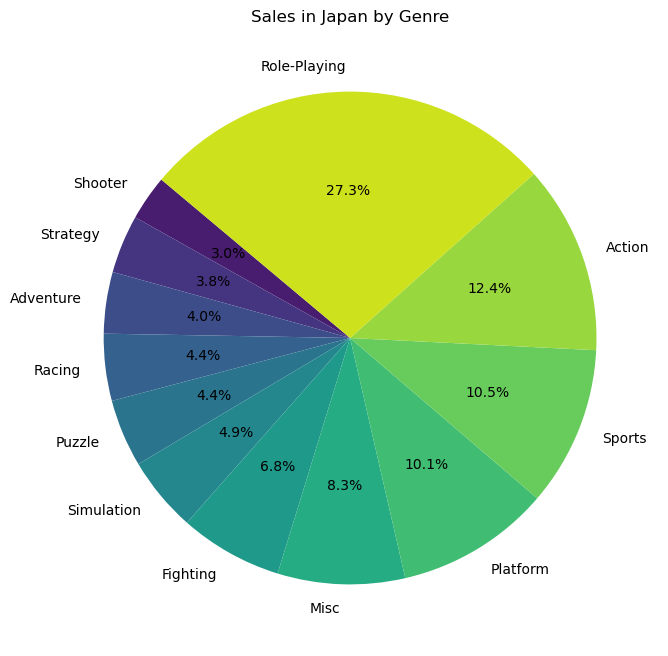

In [188]:
jp_sales_by_genre = data.groupby('genre')['jp_sales'].sum().sort_values(ascending=True)

colors = sns.color_palette('viridis', len(global_sales_by_genre))

plt.figure(figsize=(8,8))
plt.pie(jp_sales_by_genre, labels=jp_sales_by_genre.index, autopct='%1.1f%%', startangle=140, colors=colors)

plt.title("Sales in Japan by Genre")


plt.show()


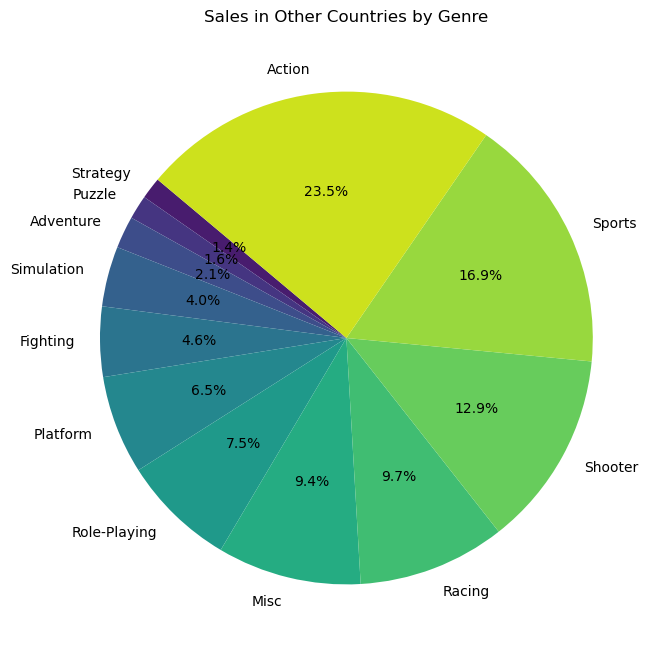

In [189]:
other_sales_by_genre = data.groupby('genre')['other_sales'].sum().sort_values(ascending=True)


colors = sns.color_palette('viridis', len(global_sales_by_genre))

plt.figure(figsize=(8,8))
plt.pie(other_sales_by_genre, labels=other_sales_by_genre.index, autopct='%1.1f%%', startangle=140, colors=colors)

plt.title("Sales in Other Countries by Genre")

plt.show()

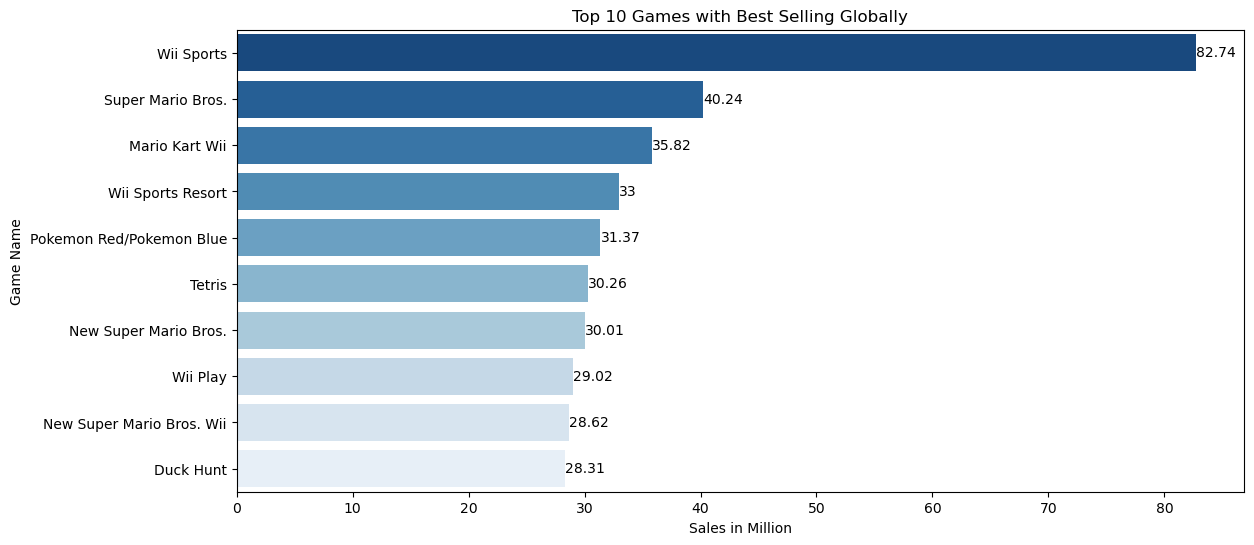

In [230]:

top_10_games_global = data[['name', 'global_sales']].sort_values(by='global_sales', ascending=False).head(10)


plt.figure(figsize=(13,6))
ax_global_games = sns.barplot(x='global_sales', y='name', data=top_10_games_global, palette='Blues_r')


ax_global_games.bar_label(ax_global_games.containers[0])

plt.title("Top 10 Games with Best Selling Globally")
plt.xlabel("Sales in Million")
plt.ylabel("Game Name")


plt.show()



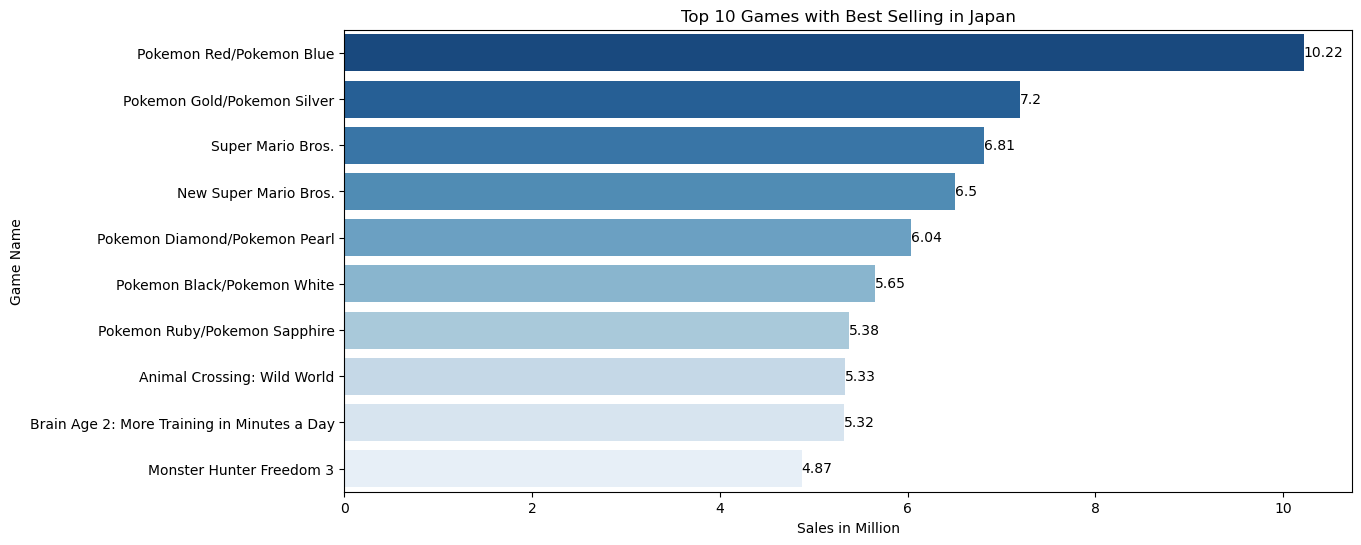

In [231]:

top_10_games_jp = data[['name', 'jp_sales']].sort_values(by='jp_sales', ascending=False).head(10)


plt.figure(figsize=(13,6))
ax_jp_games = sns.barplot(x='jp_sales', y='name', data=top_10_games_jp, palette='Blues_r')


ax_jp_games.bar_label(ax_jp_games.containers[0])

plt.title("Top 10 Games with Best Selling in Japan")
plt.xlabel("Sales in Million")
plt.ylabel("Game Name")


plt.show()

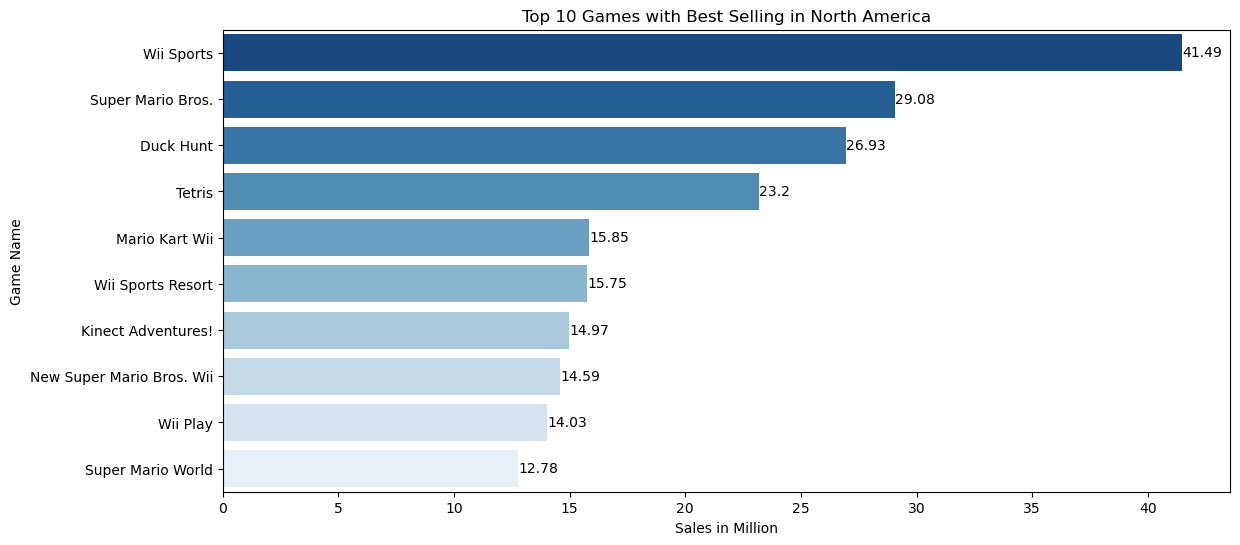

In [225]:

top_10_games_na = data[['name', 'na_sales']].sort_values(by='na_sales', ascending=False).head(10)


plt.figure(figsize=(13,6))
ax_na_games = sns.barplot(x='na_sales', y='name', data=top_10_games_na, palette='Blues_r')

ax_na_games.bar_label(ax_na_games.containers[0])


plt.title("Top 10 Games with Best Selling in North America")
plt.xlabel("Sales in Million")
plt.ylabel("Game Name")


plt.show()

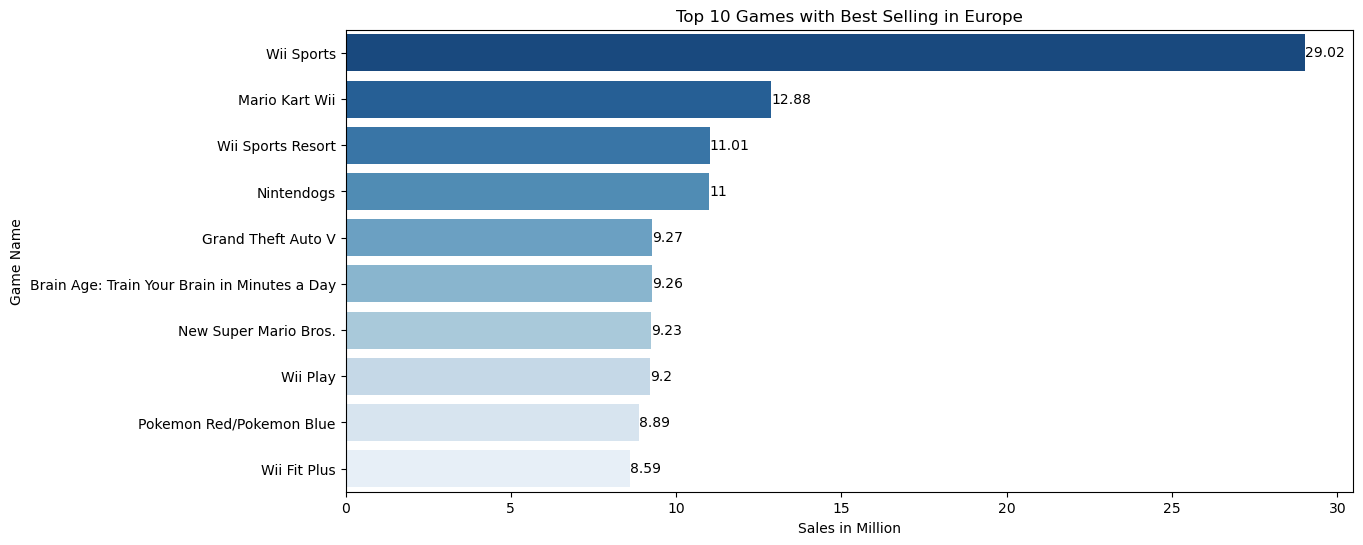

In [227]:

top_10_games_eu = data[['name', 'eu_sales']].sort_values(by='eu_sales', ascending=False).head(10)


plt.figure(figsize=(13,6))
ax_eu_games = sns.barplot(x='eu_sales', y='name', data=top_10_games_eu, palette='Blues_r')


ax_eu_games.bar_label(ax_eu_games.containers[0])

plt.title("Top 10 Games with Best Selling in Europe")
plt.xlabel("Sales in Million")
plt.ylabel("Game Name")


plt.show()

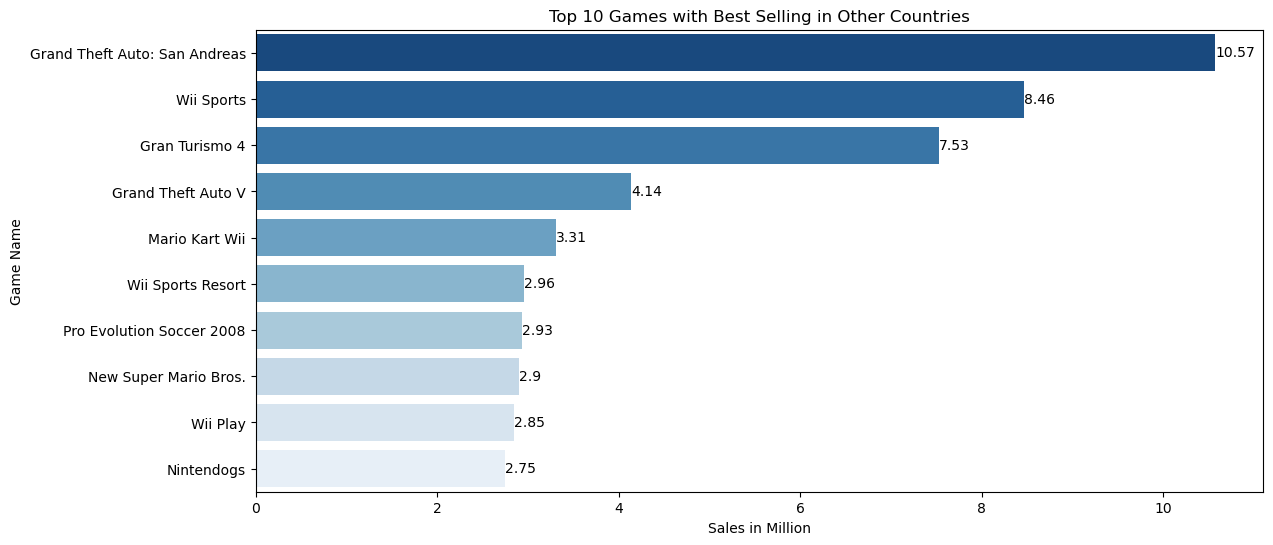

In [229]:

top_10_games_other = data[['name', 'other_sales']].sort_values(by='other_sales', ascending=False).head(10)


plt.figure(figsize=(13,6))
ax_other_games = sns.barplot(x='other_sales', y='name', data=top_10_games_other, palette='Blues_r')


ax_other_games.bar_label(ax_other_games.containers[0])

plt.title("Top 10 Games with Best Selling in Other Countries")
plt.xlabel("Sales in Million")
plt.ylabel("Game Name")


plt.show()

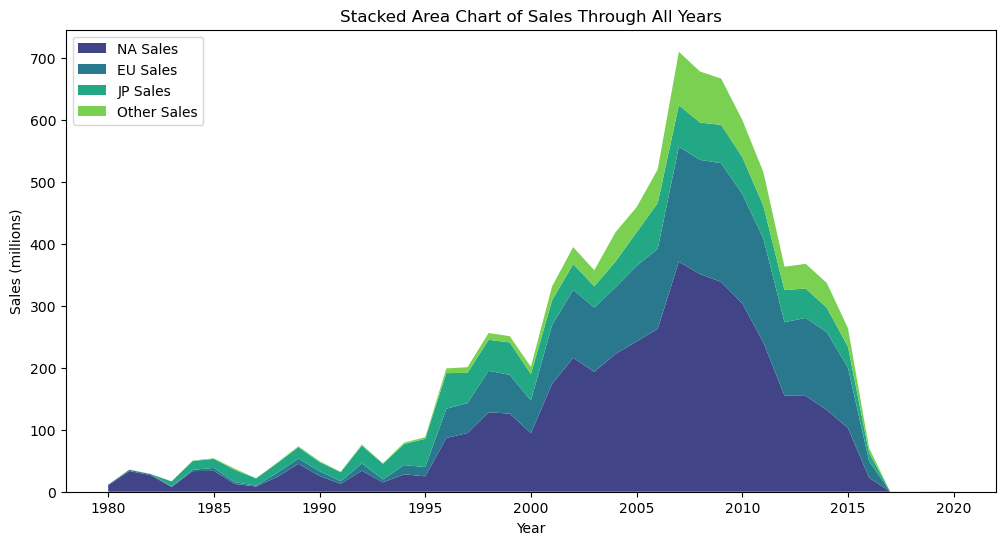

In [171]:
# Ensure 'year' column is in integer format and remove any NaN values
data['year'] = pd.to_numeric(data['year'], errors='coerce')
data.dropna(subset=['year'], inplace=True)
data['year'] = data['year'].astype(int)

# Grouping the data by year and summing the sales in each region
sales_by_year = data.groupby('year')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()

# Plotting the stacked area chart
plt.figure(figsize=(12, 6))
plt.stackplot(sales_by_year.index, 
              sales_by_year['na_sales'], 
              sales_by_year['eu_sales'], 
              sales_by_year['jp_sales'], 
              sales_by_year['other_sales'], 
              labels=['NA Sales', 'EU Sales', 'JP Sales', 'Other Sales'], 
              colors=sns.color_palette('viridis', 4))

# Adding labels, title, and legend
plt.title('Stacked Area Chart of Sales Through All Years')
plt.xlabel('Year')
plt.ylabel('Sales (millions)')
plt.legend(loc='upper left')
plt.show()






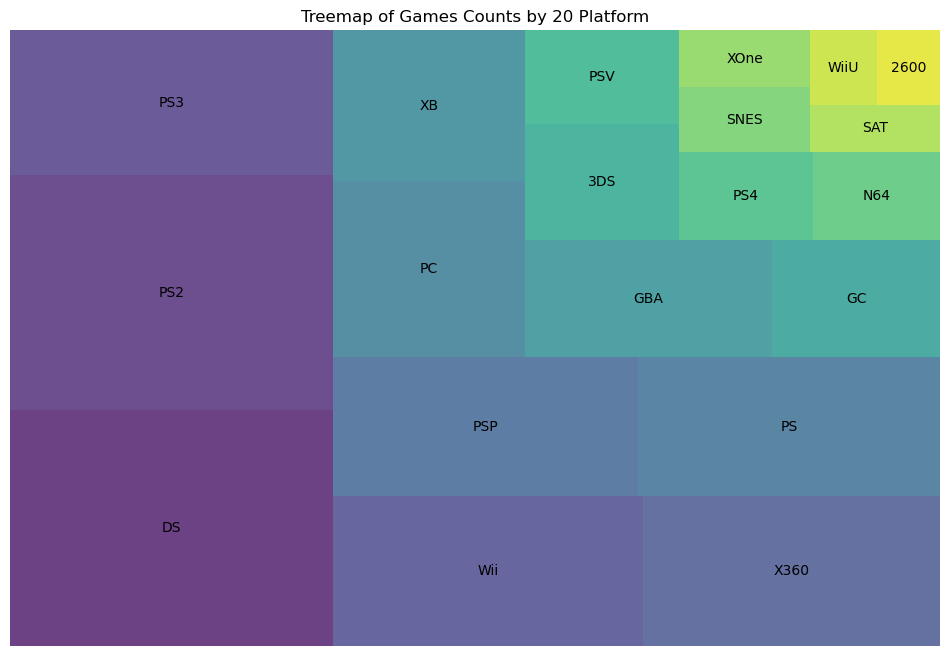

In [200]:
platform_game_count = data['platform'].value_counts().head(20)

plt.figure(figsize=(12, 8))
squarify.plot(sizes=platform_game_count.values, label=platform_game_count.index, alpha=0.8, color=sns.color_palette('viridis', len(platform_game_count)))
plt.title('Treemap of Games Counts by 20 Platform')
plt.axis('off')
plt.show()